<a href="https://colab.research.google.com/github/ramyamail2-collab/Facial-Emotion-Recognition-using-OpenCV-and-Deepface/blob/main/ANPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
pip install opencv-python pytesseract numpy


🔍 Detected Plate: KLO2BM4659
📍 Processed at: 2026-04-06 12:09:05


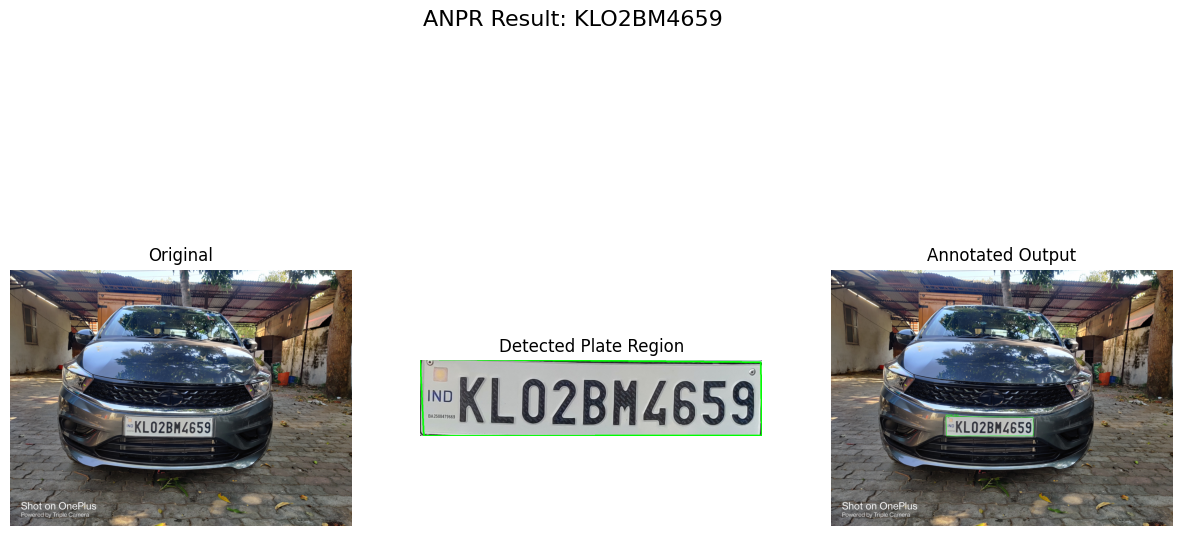

In [31]:
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# ==================== CONFIG ====================
# This path needs to point to the Tesseract executable.
# In Google Colab, Tesseract is often installed at /usr/bin/tesseract.
# If Tesseract is not installed, you might need to run: !sudo apt-get install tesseract-ocr
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'  # CHANGED FOR COLAB ENVIRONMENT
CUSTOM_CONFIG = r'--oem 3 --psm 8 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'  # Indian plates

# ==================== FUNCTIONS ====================
def preprocess_image(image):
    """1. Image Preprocessing"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    return gray, blurred

def detect_plate(image):
    """2-4. Edge detection + Contour extraction + ROI"""
    gray, blurred = preprocess_image(image)

    # Edge detection
    edged = cv2.Canny(blurred, 30, 200)

    # Find contours
    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    plate_contour = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:  # Rectangle
            plate_contour = approx
            break

    if plate_contour is None:
        return None, None

    # Crop ROI
    x, y, w, h = cv2.boundingRect(plate_contour)
    plate_roi = image[y:y+h, x:x+w]

    # Draw bounding box on original
    cv2.drawContours(image, [plate_contour], -1, (0, 255, 0), 3)
    cv2.putText(image, "Number Plate", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    return plate_roi, image

def ocr_plate(plate_roi):
    """5. Optical Character Recognition"""
    if plate_roi is None:
        return "No plate detected"

    # Extra preprocessing for OCR
    gray = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    # OCR
    text = pytesseract.image_to_string(thresh, config=CUSTOM_CONFIG).strip()
    return text

# ==================== MAIN EXECUTION ====================
def process_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image")
        return

    plate_roi, annotated_image = detect_plate(image.copy())
    plate_text = ocr_plate(plate_roi)

    print(f"\n🔍 Detected Plate: {plate_text}")
    print(f"📍 Processed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Display results
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Detected Plate Region")
    if plate_roi is not None:
        plt.imshow(cv2.cvtColor(plate_roi, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Annotated Output")
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.suptitle(f"ANPR Result: {plate_text}", fontsize=16)
    plt.show()

    return plate_text

# ==================== BATCH PROCESSING & ACCURACY EVALUATION ====================
def evaluate_accuracy(test_folder, ground_truth_dict):
    """Accuracy evaluation module"""
    correct = 0
    total = 0
    results = []

    for filename in os.listdir(test_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(test_folder, filename)
            predicted = process_image(path)  # processes and shows plot
            actual = ground_truth_dict.get(filename, "").upper().replace(" ", "")

            total += 1
            if predicted.replace(" ", "") == actual:
                correct += 1
                status = "✅ Match"
            else:
                status = f"❌ Mismatch (Pred: {predicted}, Actual: {actual})"

            results.append((filename, predicted, actual, status))
            print(f"{filename}: {status}")

    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"\n🎯 Overall Accuracy: {accuracy:.2f}% ({correct}/{total})")
    return results, accuracy

# ==================== USAGE ====================
if __name__ == "__main__":
    # Single image test
    process_image('/content/Datacluster_number_plates (16).jpg') # Changed to use available TEST_IMAGE_PATH

    # Batch evaluation (create ground_truth_dict from your dataset labels)
    # ground_truth = {"image001.jpg": "TN 07 AB 1234", ...}
    # evaluate_accuracy("dataset/test_images", ground_truth)
